# Chatbot Analytics and Optimisation

**Use case:** E-commerce customer support  
**Dataset:** Bitext Sample Customer Service Training Dataset  
**Environment:** Google Colab / Python

This notebook covers the practical analytics work for the assignment: EDA, intent classification, fallback analysis, simulated user segmentation, robustness checks and a final dashboard. Longer business discussion is kept for the report.

In [1]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np

print("Setup completed successfully.")

Setup completed successfully.


In [3]:
PROJECT_DIR = "/content/drive/MyDrive/CBAO_Assignment_2"

RAW_DATA_DIR = os.path.join(PROJECT_DIR, "01_Dataset", "raw")
PROCESSED_DATA_DIR = os.path.join(PROJECT_DIR, "01_Dataset", "processed")
FIGURES_DIR = os.path.join(PROJECT_DIR, "03_Figures")

DATA_PATH = os.path.join(
    RAW_DATA_DIR,
    "Bitext_Sample_Customer_Service_Training_Dataset.csv"
)

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATA_PATH)

Project directory: /content/drive/MyDrive/CBAO_Assignment_2
Dataset path: /content/drive/MyDrive/CBAO_Assignment_2/01_Dataset/raw/Bitext_Sample_Customer_Service_Training_Dataset.csv


In [4]:
print("Dataset exists:", os.path.exists(DATA_PATH))

df = pd.read_csv(DATA_PATH)
print("Dataset loaded successfully.")

df.head(5)

Dataset exists: True
Dataset loaded successfully.


,flags,utterance,category,intent
0,BM,I have problems with canceling an order,ORDER,cancel_order
1,BIM,how can I find information about canceling ord...,ORDER,cancel_order
2,B,I need help with canceling the last order,ORDER,cancel_order
3,BIP,could you help me cancelling the last order I ...,ORDER,cancel_order
4,B,problem with cancelling an order I made,ORDER,cancel_order


In [5]:
print("Dataset shape:", df.shape)
print("*" * 50)
print("Columns:")
print(df.columns.tolist())
print("*" * 50)

df.info()

Dataset shape: (8175, 4)
**************************************************
Columns:
['flags', 'utterance', 'category', 'intent']
**************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8175 entries, 0 to 8174
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   flags      8175 non-null   object
 1   utterance  8175 non-null   object
 2   category   8175 non-null   object
 3   intent     8175 non-null   object
dtypes: object(4)
memory usage: 255.6+ KB


In [6]:
print("Number of unique intents:", df["intent"].nunique())
print("Number of unique categories:", df["category"].nunique())
print("*" * 50)

sorted(df["intent"].unique())

Number of unique intents: 27
Number of unique categories: 11
**************************************************


['cancel_order',
 'change_order',
 'change_shipping_address',
 'check_cancellation_fee',
 'check_invoice',
 'check_payment_methods',
 'check_refund_policy',
 'complaint',
 'contact_customer_service',
 'contact_human_agent',
 'create_account',
 'delete_account',
 'delivery_options',
 'delivery_period',
 'edit_account',
 'get_invoice',
 'get_refund',
 'newsletter_subscription',
 'payment_issue',
 'place_order',
 'recover_password',
 'registration_problems',
 'review',
 'set_up_shipping_address',
 'switch_account',
 'track_order',
 'track_refund']

## 2. Data Cleaning and EDA

I first checked data quality, class balance and message length before training the intent model.

In [7]:
# Data quality overview

quality_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Unique Values": df.nunique(),
    "Data Type": df.dtypes.astype(str)
})

display(quality_summary)

print("\nTotal rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate utterances:", df["utterance"].duplicated().sum())

,Missing Values,Unique Values,Data Type
flags,0,118,object
utterance,0,8175,object
category,0,11,object
intent,0,27,object



Total rows: 8175
Duplicate rows: 0
Duplicate utterances: 0


In [8]:
# Create a clean working copy while preserving the original raw dataset

df_clean = df.copy()

text_columns = ["flags", "utterance", "category", "intent"]

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip()

# Remove exact duplicate rows if any exist
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Check for empty strings after trimming whitespace
blank_counts = {
    column: (df_clean[column] == "").sum()
    for column in text_columns
}

print("Shape after cleaning:", df_clean.shape)
print("Blank values after cleaning:", blank_counts)

Shape after cleaning: (8175, 4)
Blank values after cleaning: {'flags': np.int64(0), 'utterance': np.int64(0), 'category': np.int64(0), 'intent': np.int64(0)}


In [9]:
CLEAN_DATA_PATH = os.path.join(
    PROCESSED_DATA_DIR,
    "Bitext_Customer_Service_Cleaned.csv"
)

df_clean.to_csv(CLEAN_DATA_PATH, index=False)

print("Clean dataset saved to:")
print(CLEAN_DATA_PATH)

Clean dataset saved to:
/content/drive/MyDrive/CBAO_Assignment_2/01_Dataset/processed/Bitext_Customer_Service_Cleaned.csv


In [10]:
eda_df = df_clean.copy()

eda_df["word_count"] = eda_df["utterance"].str.split().str.len()
eda_df["char_count"] = eda_df["utterance"].str.len()

display(
    eda_df[["word_count", "char_count"]]
    .describe()
    .round(2)
)

,word_count,char_count
count,8175.00,8175.00
mean,8.32,42.57
std,2.39,10.58
min,1.00,6.00
25%,7.00,35.00
50%,8.00,43.00
75%,10.00,51.00
max,15.00,60.00


In [11]:
intent_counts = (
    eda_df["intent"]
    .value_counts()
    .sort_values(ascending=False)
)

display(
    intent_counts
    .rename("Number of Utterances")
    .to_frame()
)

print("Minimum examples in an intent:", intent_counts.min())
print("Maximum examples in an intent:", intent_counts.max())

imbalance_ratio = intent_counts.max() / intent_counts.min()

print("Class imbalance ratio:", round(imbalance_ratio, 2))

,Number of Utterances
intent,
check_invoice,324
get_invoice,324
payment_issue,323
review,315
track_refund,308
set_up_shipping_address,307
place_order,306
cancel_order,305
track_order,305


Minimum examples in an intent: 290
Maximum examples in an intent: 324
Class imbalance ratio: 1.12


In [12]:
import matplotlib.pyplot as plt

os.makedirs(FIGURES_DIR, exist_ok=True)

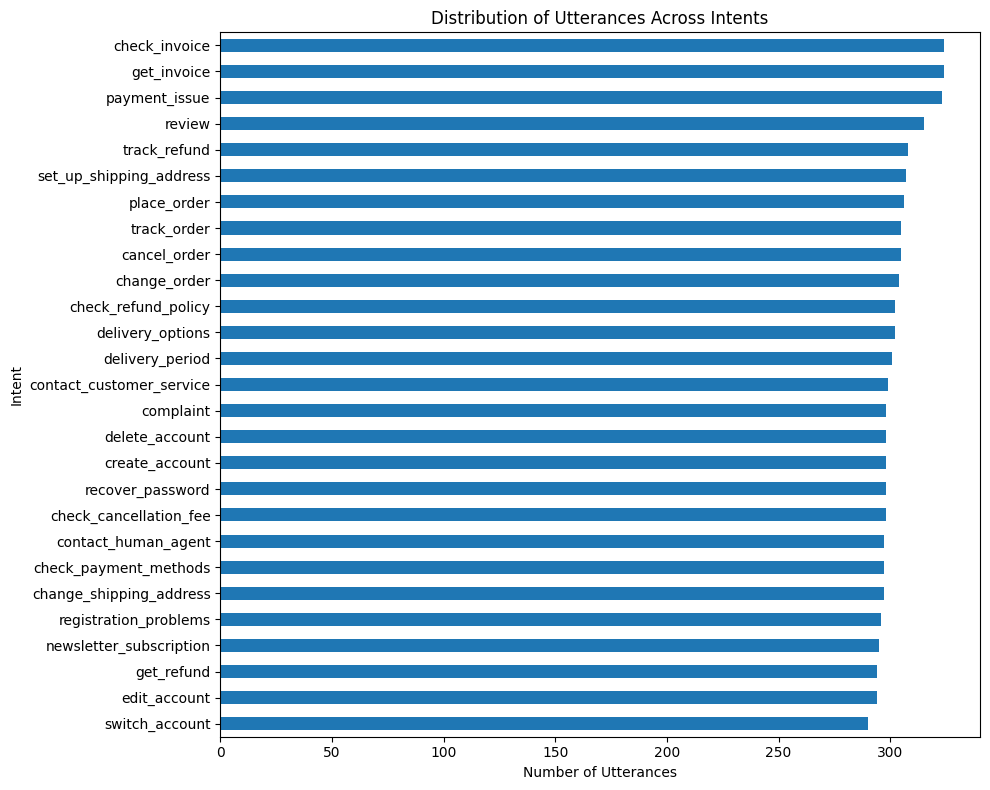

In [13]:
intent_counts_ascending = intent_counts.sort_values()

plt.figure(figsize=(10, 8))

intent_counts_ascending.plot(kind="barh")

plt.title("Distribution of Utterances Across Intents")
plt.xlabel("Number of Utterances")
plt.ylabel("Intent")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "01_intent_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [14]:
category_counts = (
    eda_df["category"]
    .value_counts()
    .sort_values(ascending=False)
)

display(
    category_counts
    .rename("Number of Utterances")
    .to_frame()
)

print("\nNumber of intents within each category:")

display(
    eda_df
    .groupby("category")["intent"]
    .nunique()
    .sort_values(ascending=False)
    .rename("Number of Intents")
    .to_frame()
)

,Number of Utterances
category,
ACCOUNT,1774
ORDER,1220
REFUND,904
INVOICE,648
PAYMENT,620
FEEDBACK,613
SHIPPING_ADDRESS,604
DELIVERY,603
CONTACT,596



Number of intents within each category:


,Number of Intents
category,
ACCOUNT,6
ORDER,4
REFUND,3
PAYMENT,2
CONTACT,2
DELIVERY,2
FEEDBACK,2
SHIPPING_ADDRESS,2
INVOICE,2


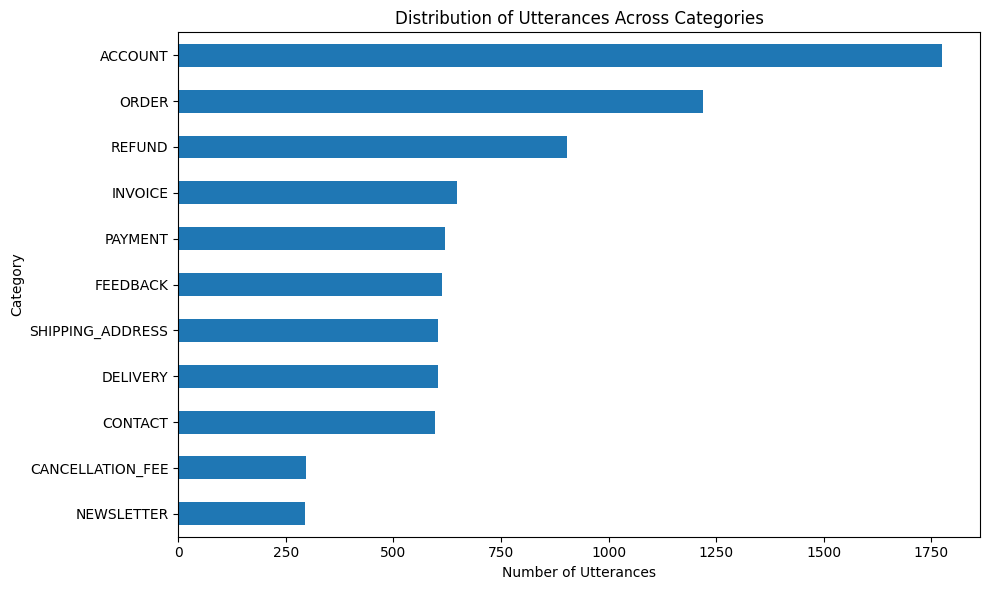

In [15]:
category_counts_ascending = category_counts.sort_values()

plt.figure(figsize=(10, 6))

category_counts_ascending.plot(kind="barh")

plt.title("Distribution of Utterances Across Categories")
plt.xlabel("Number of Utterances")
plt.ylabel("Category")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "02_category_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

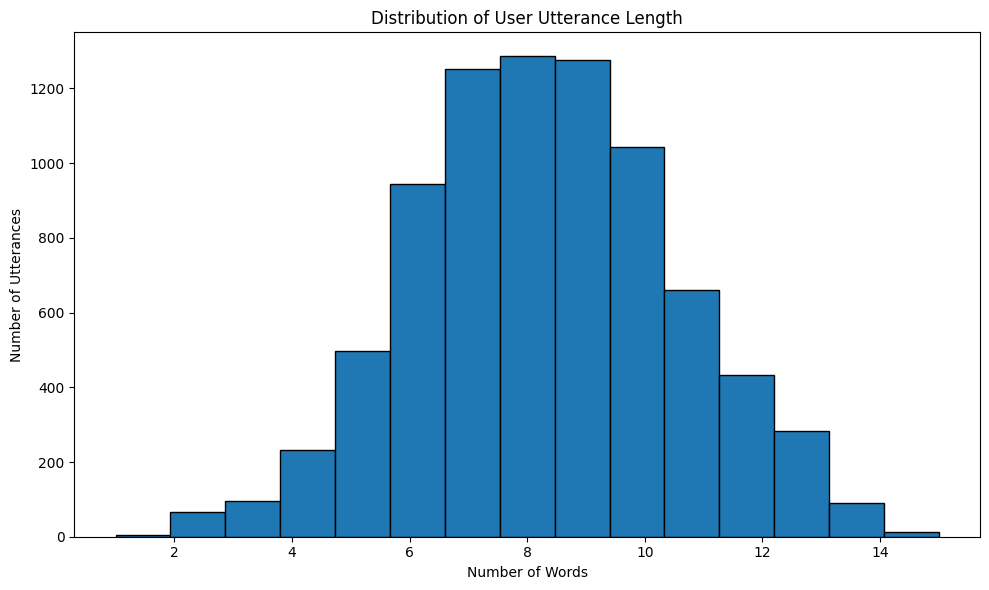

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(
    eda_df["word_count"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of User Utterance Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Utterances")

plt.tight_layout()

plt.savefig(
    os.path.join(FIGURES_DIR, "03_utterance_length_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### EDA notes

The dataset has 8,175 utterances, 27 intents and 11 categories. There were no missing or duplicate utterances. Intent classes are quite balanced (about 290–324 examples each), and messages are short on average at about eight words.

## 3. Intent Classification

I used an 80/20 stratified train-test split with a TF-IDF + Logistic Regression pipeline. Performance is reported with accuracy, precision, recall, F1 and a confusion matrix.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Machine-learning libraries imported successfully.")

Machine-learning libraries imported successfully.


In [18]:
X = df_clean["utterance"]
y = df_clean["intent"]

print("Number of utterances:", len(X))
print("Number of target labels:", len(y))
print("Number of unique intents:", y.nunique())

Number of utterances: 8175
Number of target labels: 8175
Number of unique intents: 27


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining intents:", y_train.nunique())
print("Testing intents:", y_test.nunique())

Training samples: 6540
Testing samples: 1635

Training intents: 27
Testing intents: 27


In [20]:
intent_model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1500,
            random_state=42
        )
    )
])

print(intent_model)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(min_df=2, ngram_range=(1, 2),
                                 sublinear_tf=True)),
                ('classifier',
                 LogisticRegression(max_iter=1500, random_state=42))])


In [21]:
intent_model.fit(X_train, y_train)

print("Intent classification model trained successfully.")

Intent classification model trained successfully.


In [22]:
y_pred = intent_model.predict(X_test)

prediction_probabilities = intent_model.predict_proba(X_test)

prediction_confidence = prediction_probabilities.max(axis=1)

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

Predictions completed.
Number of predictions: 1635


In [23]:
accuracy = accuracy_score(y_test, y_pred)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

metrics_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1-score"
    ],
    "Score": [
        accuracy,
        macro_precision,
        macro_recall,
        macro_f1
    ]
})

display(
    metrics_summary.assign(
        Score=metrics_summary["Score"].round(4)
    )
)

,Metric,Score
0,Accuracy,0.9933
1,Macro Precision,0.9933
2,Macro Recall,0.9933
3,Macro F1-score,0.9933


In [24]:
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

intent_labels = sorted(y.unique())

intent_performance = (
    report_df
    .loc[intent_labels, ["precision", "recall", "f1-score", "support"]]
    .sort_values("f1-score", ascending=True)
)

intent_performance["support"] = (
    intent_performance["support"]
    .astype(int)
)

display(
    intent_performance.round(4)
)

,precision,recall,f1-score,support
create_account,0.9831,0.9667,0.9748,60
registration_problems,0.9516,1.0000,0.9752,59
cancel_order,0.9677,0.9836,0.9756,61
delete_account,1.0000,0.9667,0.9831,60
check_refund_policy,0.9833,0.9833,0.9833,60
check_cancellation_fee,0.9677,1.0000,0.9836,60
payment_issue,1.0000,0.9692,0.9844,65
get_refund,1.0000,0.9831,0.9915,59
switch_account,0.9831,1.0000,0.9915,58
change_shipping_address,0.9833,1.0000,0.9916,59


In [25]:
print("Five weakest intents by F1-score:")

display(
    intent_performance
    .head(5)
    .round(4)
)

Five weakest intents by F1-score:


,precision,recall,f1-score,support
create_account,0.9831,0.9667,0.9748,60
registration_problems,0.9516,1.0000,0.9752,59
cancel_order,0.9677,0.9836,0.9756,61
delete_account,1.0000,0.9667,0.9831,60
check_refund_policy,0.9833,0.9833,0.9833,60


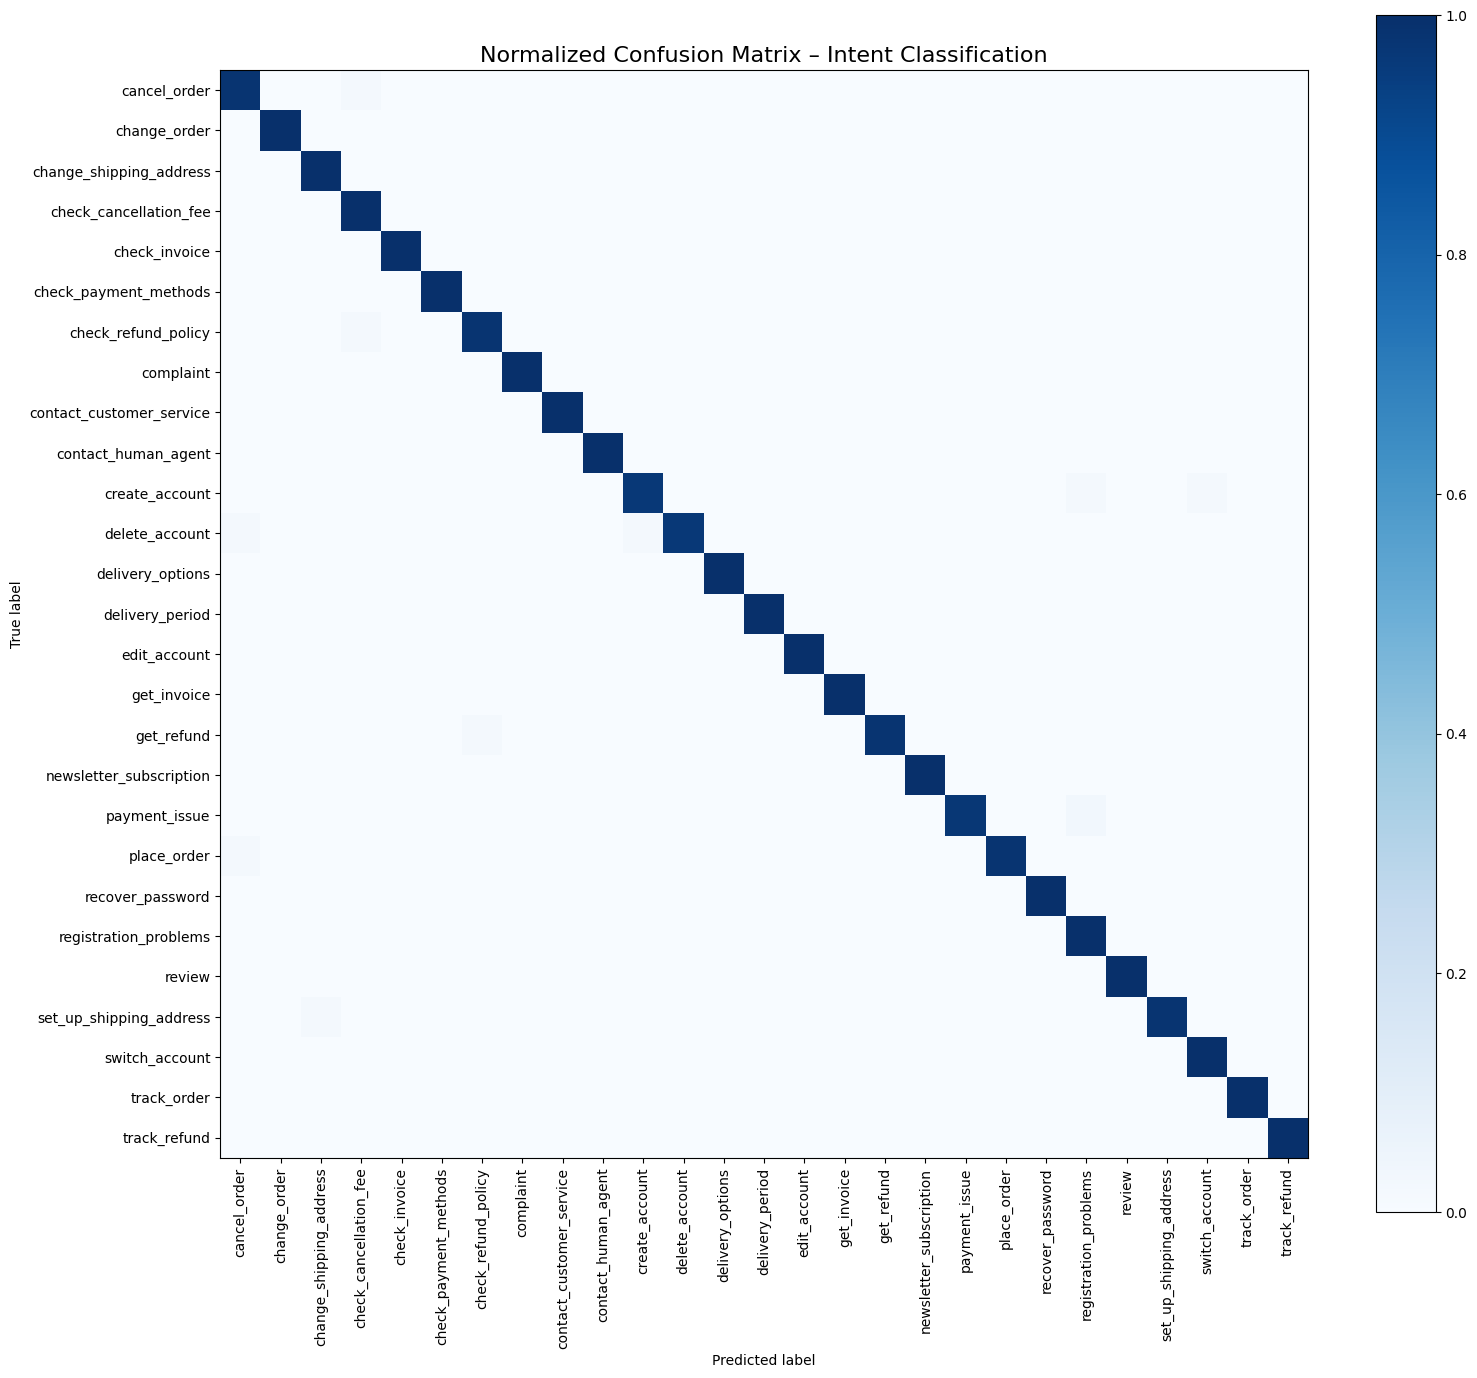

In [26]:
labels = np.array(sorted(y.unique()))

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=labels,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(16, 14))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    include_values=False,
    xticks_rotation=90,
    colorbar=True
)

plt.title(
    "Normalized Confusion Matrix – Intent Classification",
    fontsize=16
)

plt.tight_layout()

CONFUSION_MATRIX_PATH = os.path.join(
    FIGURES_DIR,
    "04_intent_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
cm_counts = confusion_matrix(
    y_test,
    y_pred,
    labels=labels
)

confusion_pairs = []

for i in range(len(labels)):
    for j in range(i + 1, len(labels)):

        a_to_b = int(cm_counts[i, j])
        b_to_a = int(cm_counts[j, i])

        total_confusions = a_to_b + b_to_a

        if total_confusions > 0:

            confusion_pairs.append({
                "Intent A": labels[i],
                "Intent B": labels[j],
                "A → B": a_to_b,
                "B → A": b_to_a,
                "Total Confusions": total_confusions
            })

confusion_pairs_df = (
    pd.DataFrame(confusion_pairs)
    .sort_values(
        "Total Confusions",
        ascending=False
    )
    .reset_index(drop=True)
)

print("Most frequent intent confusions:")

display(
    confusion_pairs_df.head(10)
)

Most frequent intent confusions:


,Intent A,Intent B,A → B,B → A,Total Confusions
0,payment_issue,registration_problems,2,0,2
1,cancel_order,check_cancellation_fee,1,0,1
2,cancel_order,delete_account,0,1,1
3,cancel_order,place_order,0,1,1
4,check_cancellation_fee,check_refund_policy,0,1,1
5,change_shipping_address,set_up_shipping_address,0,1,1
6,check_refund_policy,get_refund,0,1,1
7,create_account,delete_account,0,1,1
8,create_account,registration_problems,1,0,1
9,create_account,switch_account,1,0,1


In [28]:
test_results = pd.DataFrame({
    "utterance": X_test.reset_index(drop=True),
    "actual_intent": y_test.reset_index(drop=True),
    "predicted_intent": y_pred,
    "confidence": prediction_confidence
})

test_results["correct"] = (
    test_results["actual_intent"]
    == test_results["predicted_intent"]
)

display(
    test_results.head()
)

,utterance,actual_intent,predicted_intent,confidence,correct
0,i need help speaking to a live agent,contact_human_agent,contact_human_agent,0.512677,True
1,can I use another account?,switch_account,switch_account,0.830761,True
2,I don't know how I could check my refund status,track_refund,track_refund,0.862645,True
3,I need help to modify the data included on my ...,edit_account,edit_account,0.827061,True
4,assistance to check the invoices from last month,check_invoice,check_invoice,0.911477,True


### Model notes

The model reached about **99.33% accuracy and Macro F1** on the held-out test set. The score is high, so the next sections focus more on uncertainty, fallback behaviour and difficult input types than on trying to increase accuracy further.

## 4. Fallback Analysis

The model's highest predicted probability is used as a confidence score. I tested several thresholds to see when the chatbot should answer and when it should fall back.

In [29]:
thresholds = [0.30, 0.40, 0.50, 0.60]

total_predictions = len(test_results)
total_errors = (~test_results["correct"]).sum()

threshold_analysis = []

for threshold in thresholds:

    fallback_mask = (
        test_results["confidence"] < threshold
    )

    handled_mask = ~fallback_mask

    fallback_count = fallback_mask.sum()
    handled_count = handled_mask.sum()

    fallback_rate = (
        fallback_count / total_predictions
    )

    coverage = (
        handled_count / total_predictions
    )

    accepted_accuracy = (
        test_results.loc[
            handled_mask,
            "correct"
        ].mean()
    )

    errors_captured = (
        (~test_results["correct"])
        & fallback_mask
    ).sum()

    error_capture_rate = (
        errors_captured / total_errors
        if total_errors > 0
        else 0
    )

    correct_sent_to_fallback = (
        test_results["correct"]
        & fallback_mask
    ).sum()

    threshold_analysis.append({
        "Threshold": threshold,
        "Fallback Count": int(fallback_count),
        "Fallback Rate": fallback_rate,
        "Coverage": coverage,
        "Accepted Accuracy": accepted_accuracy,
        "Errors Captured": int(errors_captured),
        "Error Capture Rate": error_capture_rate,
        "Correct Predictions Sent to Fallback":
            int(correct_sent_to_fallback)
    })


threshold_results = pd.DataFrame(
    threshold_analysis
)

display(
    threshold_results.round(4)
)

,Threshold,Fallback Count,Fallback Rate,Coverage,Accepted Accuracy,Errors Captured,Error Capture Rate,Correct Predictions Sent to Fallback
0,0.3,23,0.0141,0.9859,0.9981,8,0.7273,15
1,0.4,44,0.0269,0.9731,0.9994,10,0.9091,34
2,0.5,89,0.0544,0.9456,0.9994,10,0.9091,79
3,0.6,157,0.0960,0.9040,0.9993,10,0.9091,147


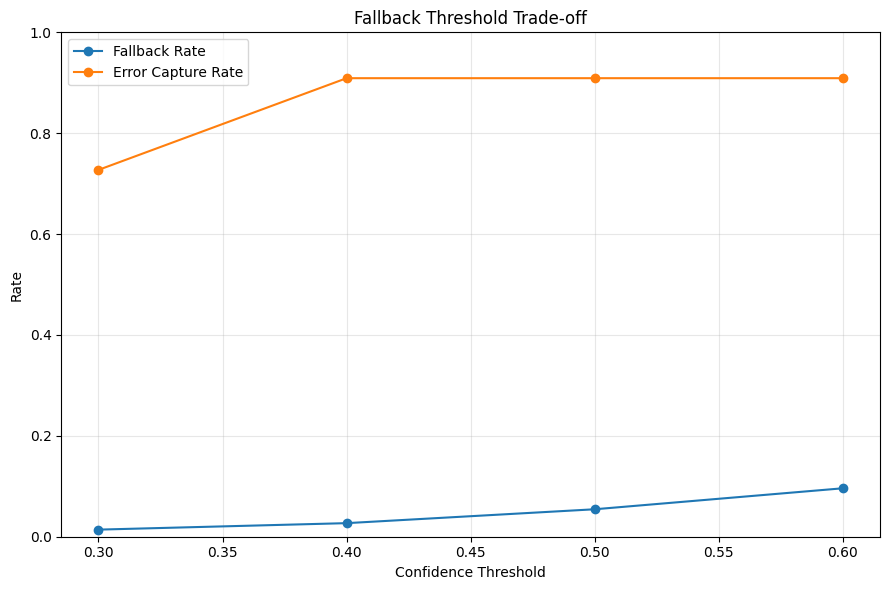

In [30]:
plt.figure(figsize=(9, 6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Fallback Rate"],
    marker="o",
    label="Fallback Rate"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Error Capture Rate"],
    marker="o",
    label="Error Capture Rate"
)

plt.xlabel("Confidence Threshold")
plt.ylabel("Rate")
plt.title(
    "Fallback Threshold Trade-off"
)

plt.ylim(0, 1)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

THRESHOLD_FIGURE_PATH = os.path.join(
    FIGURES_DIR,
    "05_fallback_threshold_tradeoff.png"
)

plt.savefig(
    THRESHOLD_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
SELECTED_THRESHOLD = 0.40

print(
    "Selected working fallback threshold:",
    SELECTED_THRESHOLD
)

Selected working fallback threshold: 0.4


In [32]:
fallback_results = (
    test_results.copy()
)

fallback_results["fallback"] = (
    fallback_results["confidence"]
    < SELECTED_THRESHOLD
)

fallback_rate = (
    fallback_results["fallback"].mean()
)

print(
    "Fallback count:",
    fallback_results["fallback"].sum()
)

print(
    "Fallback rate:",
    round(fallback_rate, 4)
)

print(
    "Fallback rate (%):",
    round(fallback_rate * 100, 2)
)

Fallback count: 44
Fallback rate: 0.0269
Fallback rate (%): 2.69


In [33]:
incorrect_predictions = (
    ~fallback_results["correct"]
)

errors_captured = (
    incorrect_predictions
    & fallback_results["fallback"]
).sum()

errors_not_captured = (
    incorrect_predictions
    & ~fallback_results["fallback"]
).sum()

print(
    "Total classification errors:",
    incorrect_predictions.sum()
)

print(
    "Errors captured by fallback:",
    errors_captured
)

print(
    "Errors NOT captured by fallback:",
    errors_not_captured
)

print(
    "Error capture rate (%):",
    round(
        errors_captured
        / incorrect_predictions.sum()
        * 100,
        2
    )
)

Total classification errors: 11
Errors captured by fallback: 10
Errors NOT captured by fallback: 1
Error capture rate (%): 90.91


In [34]:
correct_predictions_fallback = (
    fallback_results["correct"]
    & fallback_results["fallback"]
).sum()

print(
    "Correct predictions sent to fallback:",
    correct_predictions_fallback
)

print(
    "Percentage of all test queries:",
    round(
        correct_predictions_fallback
        / len(fallback_results)
        * 100,
        2
    ),
    "%"
)

Correct predictions sent to fallback: 34
Percentage of all test queries: 2.08 %


In [35]:
accepted_predictions = (
    fallback_results[
        ~fallback_results["fallback"]
    ]
)

accepted_accuracy = (
    accepted_predictions["correct"].mean()
)

print(
    "Accepted predictions:",
    len(accepted_predictions)
)

print(
    "Accuracy among accepted predictions:",
    round(
        accepted_accuracy,
        4
    )
)

print(
    "Accuracy among accepted predictions (%):",
    round(
        accepted_accuracy * 100,
        2
    ),
    "%"
)

Accepted predictions: 1591
Accuracy among accepted predictions: 0.9994
Accuracy among accepted predictions (%): 99.94 %


In [36]:
low_confidence_examples = (
    fallback_results[
        fallback_results["fallback"]
    ]
    .sort_values(
        "confidence",
        ascending=True
    )
)

display(
    low_confidence_examples[
        [
            "utterance",
            "actual_intent",
            "predicted_intent",
            "confidence",
            "correct"
        ]
    ]
    .head(15)
)

,utterance,actual_intent,predicted_intent,confidence,correct
456,are the service charges refundable?,check_refund_policy,check_cancellation_fee,0.152169,False
1620,I want help cancelling my plus account,delete_account,delete_account,0.166768,True
1469,i do not understand anything usay can uirect t...,contact_human_agent,contact_human_agent,0.180946,True
1408,how can I find information about editing the d...,change_shipping_address,change_shipping_address,0.192567,True
1052,making order,place_order,cancel_order,0.197544,False
1255,do you accept Google Pay?,check_payment_methods,check_payment_methods,0.214375,True
1134,I have a problem with the cancellation of an o...,delete_account,delete_account,0.219630,True
1619,there are issues with the sxignup,registration_problems,registration_problems,0.221338,True
1101,i want assistance retrieving my pwd,recover_password,recover_password,0.227036,True
945,i need assistance cancelling an online acfcount,delete_account,cancel_order,0.228988,False


In [37]:
captured_errors = (
    fallback_results[
        (~fallback_results["correct"])
        & fallback_results["fallback"]
    ]
    .sort_values(
        "confidence"
    )
)

display(
    captured_errors[
        [
            "utterance",
            "actual_intent",
            "predicted_intent",
            "confidence"
        ]
    ]
)

,utterance,actual_intent,predicted_intent,confidence
456,are the service charges refundable?,check_refund_policy,check_cancellation_fee,0.152169
1052,making order,place_order,cancel_order,0.197544
945,i need assistance cancelling an online acfcount,delete_account,cancel_order,0.228988
364,help regarding payment,payment_issue,registration_problems,0.234063
1174,I do not know how I can cancel an online account,delete_account,create_account,0.249551
1478,help regarding payments,payment_issue,registration_problems,0.254259
51,order cancellation,cancel_order,check_cancellation_fee,0.283466
105,I do not know how I can ask for compensations,get_refund,check_refund_policy,0.293988
436,ohw can i sign up,create_account,registration_problems,0.364254
1346,i need assistance to craete a new user account,create_account,switch_account,0.374952


In [38]:
missed_errors = (
    fallback_results[
        (~fallback_results["correct"])
        & (~fallback_results["fallback"])
    ]
    .sort_values(
        "confidence",
        ascending=False
    )
)

display(
    missed_errors[
        [
            "utterance",
            "actual_intent",
            "predicted_intent",
            "confidence"
        ]
    ]
)

,utterance,actual_intent,predicted_intent,confidence
1467,invalid shipping address,set_up_shipping_address,change_shipping_address,0.881961


In [39]:
model_classes = (
    intent_model
    .named_steps["classifier"]
    .classes_
)


def predict_with_fallback(
    text,
    threshold=SELECTED_THRESHOLD
):

    probabilities = (
        intent_model
        .predict_proba([text])[0]
    )

    best_index = (
        probabilities.argmax()
    )

    predicted_intent = (
        model_classes[best_index]
    )

    confidence = (
        probabilities[best_index]
    )

    if confidence < threshold:

        return {
            "decision": "FALLBACK",
            "predicted_intent":
                predicted_intent,
            "confidence":
                round(float(confidence), 4)
        }

    return {
        "decision": "ACCEPT",
        "predicted_intent":
            predicted_intent,
        "confidence":
            round(float(confidence), 4)
    }

In [40]:
example_text = (
    low_confidence_examples
    .iloc[0]["utterance"]
)

print(
    "Input:",
    example_text
)

print(
    predict_with_fallback(
        example_text
    )
)

Input: are the service charges refundable?
{'decision': 'FALLBACK', 'predicted_intent': 'check_cancellation_fee', 'confidence': 0.1522}


### Fallback notes

A threshold of **0.40** gives a useful trade-off for this dataset: about **2.69%** of test messages fall back, while **10 of 11** classification errors are caught. Raising the threshold further increases fallback without catching more errors.

One error still had high confidence invalid shipping address, showing that a confidence threshold cannot catch every semantic mistake.

## 5. Robustness Check

The Bitext `flags` column was used to compare model behaviour on noisy, colloquial, offensive and polite wording.

In [41]:
test_enriched = (
    fallback_results.merge(
        df_clean[
            [
                "utterance",
                "flags",
                "category"
            ]
        ],
        on="utterance",
        how="left",
        validate="one_to_one"
    )
)

display(
    test_enriched.head()
)

,utterance,actual_intent,predicted_intent,confidence,correct,fallback,flags,category
0,i need help speaking to a live agent,contact_human_agent,contact_human_agent,0.512677,True,False,BLQ,CONTACT
1,can I use another account?,switch_account,switch_account,0.830761,True,False,BI,ACCOUNT
2,I don't know how I could check my refund status,track_refund,track_refund,0.862645,True,False,BP,REFUND
3,I need help to modify the data included on my ...,edit_account,edit_account,0.827061,True,False,BL,ACCOUNT
4,assistance to check the invoices from last month,check_invoice,check_invoice,0.911477,True,False,BM,INVOICE


In [42]:
linguistic_flags = {
    "Z": "Noise / spelling variation",
    "Q": "Colloquial language",
    "W": "Offensive language",
    "P": "Politeness variation"
}

robustness_rows = []


# Overall baseline
robustness_rows.append({
    "Group": "All Test Data",
    "Samples": len(test_enriched),
    "Accuracy":
        test_enriched["correct"].mean(),
    "Average Confidence":
        test_enriched["confidence"].mean(),
    "Fallback Rate":
        test_enriched["fallback"].mean()
})


for flag_code, description in (
    linguistic_flags.items()
):

    mask = (
        test_enriched["flags"]
        .str.contains(
            flag_code,
            regex=False,
            na=False
        )
    )

    subset = (
        test_enriched[mask]
    )

    robustness_rows.append({
        "Group": description,
        "Samples": len(subset),
        "Accuracy":
            subset["correct"].mean(),
        "Average Confidence":
            subset["confidence"].mean(),
        "Fallback Rate":
            subset["fallback"].mean()
    })


robustness_df = pd.DataFrame(
    robustness_rows
)

display(
    robustness_df.round(4)
)

,Group,Samples,Accuracy,Average Confidence,Fallback Rate
0,All Test Data,1635,0.9933,0.8101,0.0269
1,Noise / spelling variation,82,0.9634,0.6271,0.1707
2,Colloquial language,166,0.9819,0.6874,0.0783
3,Offensive language,18,1.0000,0.6027,0.1667
4,Politeness variation,250,1.0000,0.8277,0.0040


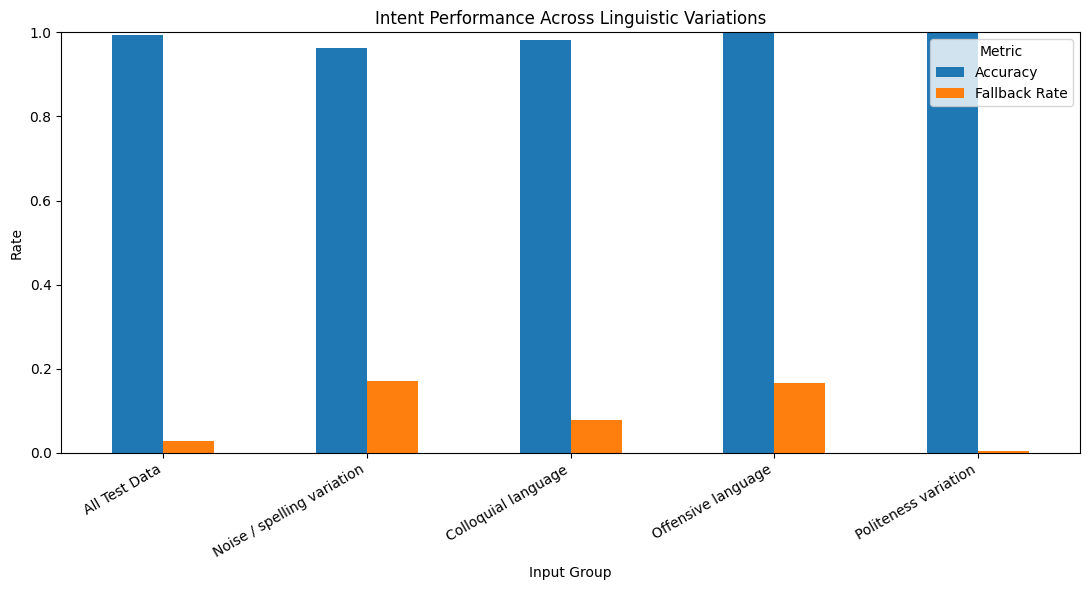

In [43]:
robustness_plot = (
    robustness_df
    .set_index("Group")
    [
        [
            "Accuracy",
            "Fallback Rate"
        ]
    ]
)

ax = robustness_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Intent Performance Across Linguistic Variations"
)

plt.ylabel("Rate")
plt.xlabel("Input Group")

plt.ylim(0, 1)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

ROBUSTNESS_FIGURE_PATH = (
    os.path.join(
        FIGURES_DIR,
        "06_linguistic_robustness.png"
    )
)

plt.savefig(
    ROBUSTNESS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Robustness notes

Overall accuracy is high, but noisy/spelling-variation messages have lower accuracy and a much higher fallback rate. This is a clearer optimisation area than the overall accuracy score suggests.

## 6. Simulated User Segmentation

The dataset has no real user IDs or session history. To demonstrate user segmentation, support interactions were grouped into four need-based segments and simple user profiles were simulated at about five interactions per profile. These profiles are only an analytical simulation, not real customers.

In [44]:
segment_mapping = {

    # Order fulfilment and delivery-related needs
    "ORDER": "Order & Delivery",
    "DELIVERY": "Order & Delivery",
    "SHIPPING_ADDRESS": "Order & Delivery",

    # Financial / refund-related needs
    "REFUND": "Refund & Billing",
    "PAYMENT": "Refund & Billing",
    "INVOICE": "Refund & Billing",
    "CANCELLATION_FEE": "Refund & Billing",

    # Account-related needs
    "ACCOUNT": "Account Management",
    "NEWSLETTER": "Account Management",

    # Customer-contact and feedback needs
    "CONTACT": "Service & Feedback",
    "FEEDBACK": "Service & Feedback"
}


segmentation_df = test_enriched.copy()

segmentation_df["segment"] = (
    segmentation_df["category"]
    .map(segment_mapping)
)

print(
    "Interactions without a segment:",
    segmentation_df["segment"].isna().sum()
)

display(
    segmentation_df[
        [
            "utterance",
            "category",
            "actual_intent",
            "segment"
        ]
    ].head(10)
)

Interactions without a segment: 0


,utterance,category,actual_intent,segment
0,i need help speaking to a live agent,CONTACT,contact_human_agent,Service & Feedback
1,can I use another account?,ACCOUNT,switch_account,Account Management
2,I don't know how I could check my refund status,REFUND,track_refund,Refund & Billing
3,I need help to modify the data included on my ...,ACCOUNT,edit_account,Account Management
4,assistance to check the invoices from last month,INVOICE,check_invoice,Refund & Billing
5,can I track my last order?,ORDER,track_order,Order & Delivery
6,can you help me solving a payment issue?,PAYMENT,payment_issue,Refund & Billing
7,report issues with registration,ACCOUNT,registration_problems,Account Management
8,get invoices,INVOICE,get_invoice,Refund & Billing
9,assistance cancelling an order,ORDER,cancel_order,Order & Delivery


In [45]:
SIMULATED_INTERACTIONS_PER_USER = 5

segmentation_df = (
    segmentation_df
    .sample(
        frac=1,
        random_state=42
    )
    .reset_index(drop=True)
)

segmentation_df[
    "interaction_index_within_segment"
] = (
    segmentation_df
    .groupby("segment")
    .cumcount()
)

segmentation_df["simulated_user_number"] = (
    segmentation_df[
        "interaction_index_within_segment"
    ]
    // SIMULATED_INTERACTIONS_PER_USER
    + 1
)


segment_codes = {
    "Order & Delivery": "ORD",
    "Refund & Billing": "REF",
    "Account Management": "ACC",
    "Service & Feedback": "SER"
}


segmentation_df["user_id"] = (
    segmentation_df["segment"]
    .map(segment_codes)
    +
    "_"
    +
    segmentation_df[
        "simulated_user_number"
    ]
    .astype(str)
    .str.zfill(3)
)

display(
    segmentation_df[
        [
            "user_id",
            "segment",
            "utterance",
            "actual_intent"
        ]
    ].head(15)
)

,user_id,segment,utterance,actual_intent
0,ORD_001,Order & Delivery,I would like to set up another shipping address,set_up_shipping_address
1,REF_001,Refund & Billing,I want help to check my refund status,track_refund
2,REF_001,Refund & Billing,how to track the refund?,track_refund
3,SER_001,Service & Feedback,help checking what hours customer service avai...,contact_customer_service
4,ORD_001,Order & Delivery,help to set a different shipping address up,set_up_shipping_address
5,SER_001,Service & Feedback,I do not know how to submit some feedback,review
6,REF_001,Refund & Billing,help me to check the invoices from last month,check_invoice
7,ACC_001,Account Management,can you help me creating an online account for...,create_account
8,SER_001,Service & Feedback,where do I file a complaint?,complaint
9,SER_001,Service & Feedback,I need help to leave a review,review


In [46]:
segment_performance = (
    segmentation_df
    .groupby("segment")
    .agg(
        interactions=(
            "utterance",
            "count"
        ),
        simulated_users=(
            "user_id",
            "nunique"
        ),
        unique_intents=(
            "actual_intent",
            "nunique"
        ),
        accuracy=(
            "correct",
            "mean"
        ),
        average_confidence=(
            "confidence",
            "mean"
        ),
        fallback_rate=(
            "fallback",
            "mean"
        ),
        classification_errors=(
            "correct",
            lambda x: (
                ~x
            ).sum()
        )
    )
    .sort_values(
        "fallback_rate",
        ascending=False
    )
)

display(
    segment_performance
    .round(4)
)

,interactions,simulated_users,unique_intents,accuracy,average_confidence,fallback_rate,classification_errors
segment,,,,,,,
Account Management,415,83,7,0.9904,0.7578,0.0578,4
Order & Delivery,484,97,8,0.9938,0.8165,0.0186,3
Refund & Billing,494,99,8,0.9919,0.8342,0.0162,4
Service & Feedback,242,49,4,1.0000,0.8380,0.0124,0


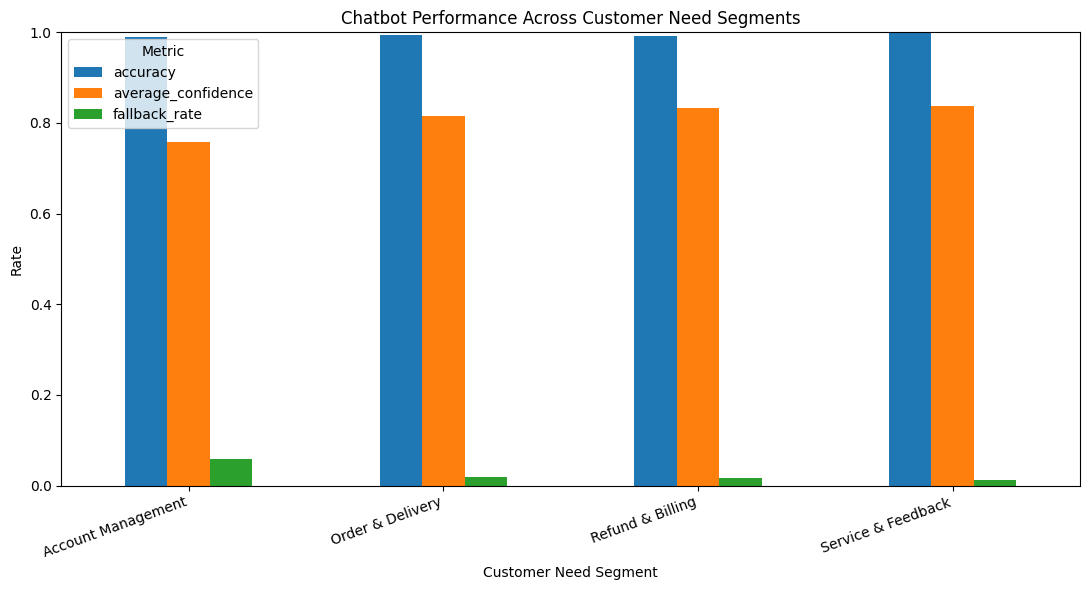

In [47]:
segment_plot = (
    segment_performance[
        [
            "accuracy",
            "average_confidence",
            "fallback_rate"
        ]
    ]
)

ax = segment_plot.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title(
    "Chatbot Performance Across Customer Need Segments"
)

plt.ylabel("Rate")
plt.xlabel("Customer Need Segment")

plt.ylim(0, 1)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.legend(
    title="Metric"
)

plt.tight_layout()

SEGMENT_FIGURE_PATH = os.path.join(
    FIGURES_DIR,
    "07_segment_performance.png"
)

plt.savefig(
    SEGMENT_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
personalisation_recommendations = pd.DataFrame({

    "Segment": [
        "Order & Delivery",
        "Refund & Billing",
        "Account Management",
        "Service & Feedback"
    ],

    "Typical Needs": [
        "Order placement, modification, tracking, delivery and shipping-address support",
        "Refunds, payments, invoices and cancellation-fee questions",
        "Account creation, editing, password recovery and subscription management",
        "Complaints, reviews, customer-service contact and human-agent requests"
    ],

    "Personalisation Strategy": [
        "Prioritise order-status shortcuts, delivery tracking and proactive shipping information.",
        "Provide clear refund/payment workflows and consider earlier escalation for financially sensitive or ambiguous requests.",
        "Prioritise account self-service options, authentication guidance and direct account-management actions.",
        "Provide rapid contact options, complaint-handling flows and easy human-agent escalation."
    ]
})

display(
    personalisation_recommendations
)

,Segment,Typical Needs,Personalisation Strategy
0,Order & Delivery,"Order placement, modification, tracking, deliv...","Prioritise order-status shortcuts, delivery tr..."
1,Refund & Billing,"Refunds, payments, invoices and cancellation-f...",Provide clear refund/payment workflows and con...
2,Account Management,"Account creation, editing, password recovery a...","Prioritise account self-service options, authe..."
3,Service & Feedback,"Complaints, reviews, customer-service contact ...","Provide rapid contact options, complaint-handl..."


### Segmentation notes

Account Management had the highest fallback rate and the lowest average confidence of the four segments. The segment table can also be used to suggest different self-service shortcuts or escalation rules. Detailed business interpretation is left for the report.

## 7. Short Optimisation Notes

The main practical findings from the analysis are:

- keep **0.40** as the working fallback threshold for this experiment;
- add more noisy and colloquial training examples;
- use clarification questions for closely related intents;
- pay extra attention to account-management flows, where confidence is lower.

Customer satisfaction, LTV, competitive advantage and wider industry implications are discussed in the written report rather than repeated here.

## 8. Frustration Scenario

The dataset does not contain real multi-turn sessions, so the example below is simulated. It starts from the real high-confidence shipping-address error found in the test set.

In [49]:
frustration_scenario = pd.DataFrame([
    {
        "Turn": 1,
        "Speaker": "User",
        "Message": "invalid shipping address",
        "System Event": "Intent prediction"
    },
    {
        "Turn": 2,
        "Speaker": "Chatbot",
        "Message": "I can help you change your existing shipping address.",
        "System Event": "Incorrect high-confidence routing"
    },
    {
        "Turn": 3,
        "Speaker": "User",
        "Message": "No, I need to set up the shipping address.",
        "System Event": "User correction"
    },
    {
        "Turn": 4,
        "Speaker": "Chatbot",
        "Message": "Please provide the shipping address you want to change.",
        "System Event": "Repeated misunderstanding"
    },
    {
        "Turn": 5,
        "Speaker": "User",
        "Message": "This is not what I asked. I already explained it. I need a human agent.",
        "System Event": "Explicit frustration and escalation request"
    },
    {
        "Turn": 6,
        "Speaker": "Chatbot",
        "Message": "I understand. I will transfer this conversation to a support agent.",
        "System Event": "Human escalation"
    }
])

pd.set_option(
    "display.max_colwidth",
    None
)

display(frustration_scenario)

,Turn,Speaker,Message,System Event
0,1,User,invalid shipping address,Intent prediction
1,2,Chatbot,I can help you change your existing shipping address.,Incorrect high-confidence routing
2,3,User,"No, I need to set up the shipping address.",User correction
3,4,Chatbot,Please provide the shipping address you want to change.,Repeated misunderstanding
4,5,User,This is not what I asked. I already explained it. I need a human agent.,Explicit frustration and escalation request
5,6,Chatbot,I understand. I will transfer this conversation to a support agent.,Human escalation


Repeated misunderstanding, user correction and an explicit request for a human agent are treated as clear recovery signals. At that point the automated flow should stop and the conversation should be escalated. The full discussion is kept for the report.

## 9. Analytics Dashboard

The dashboard brings the main model, fallback, segment and robustness results into one view.

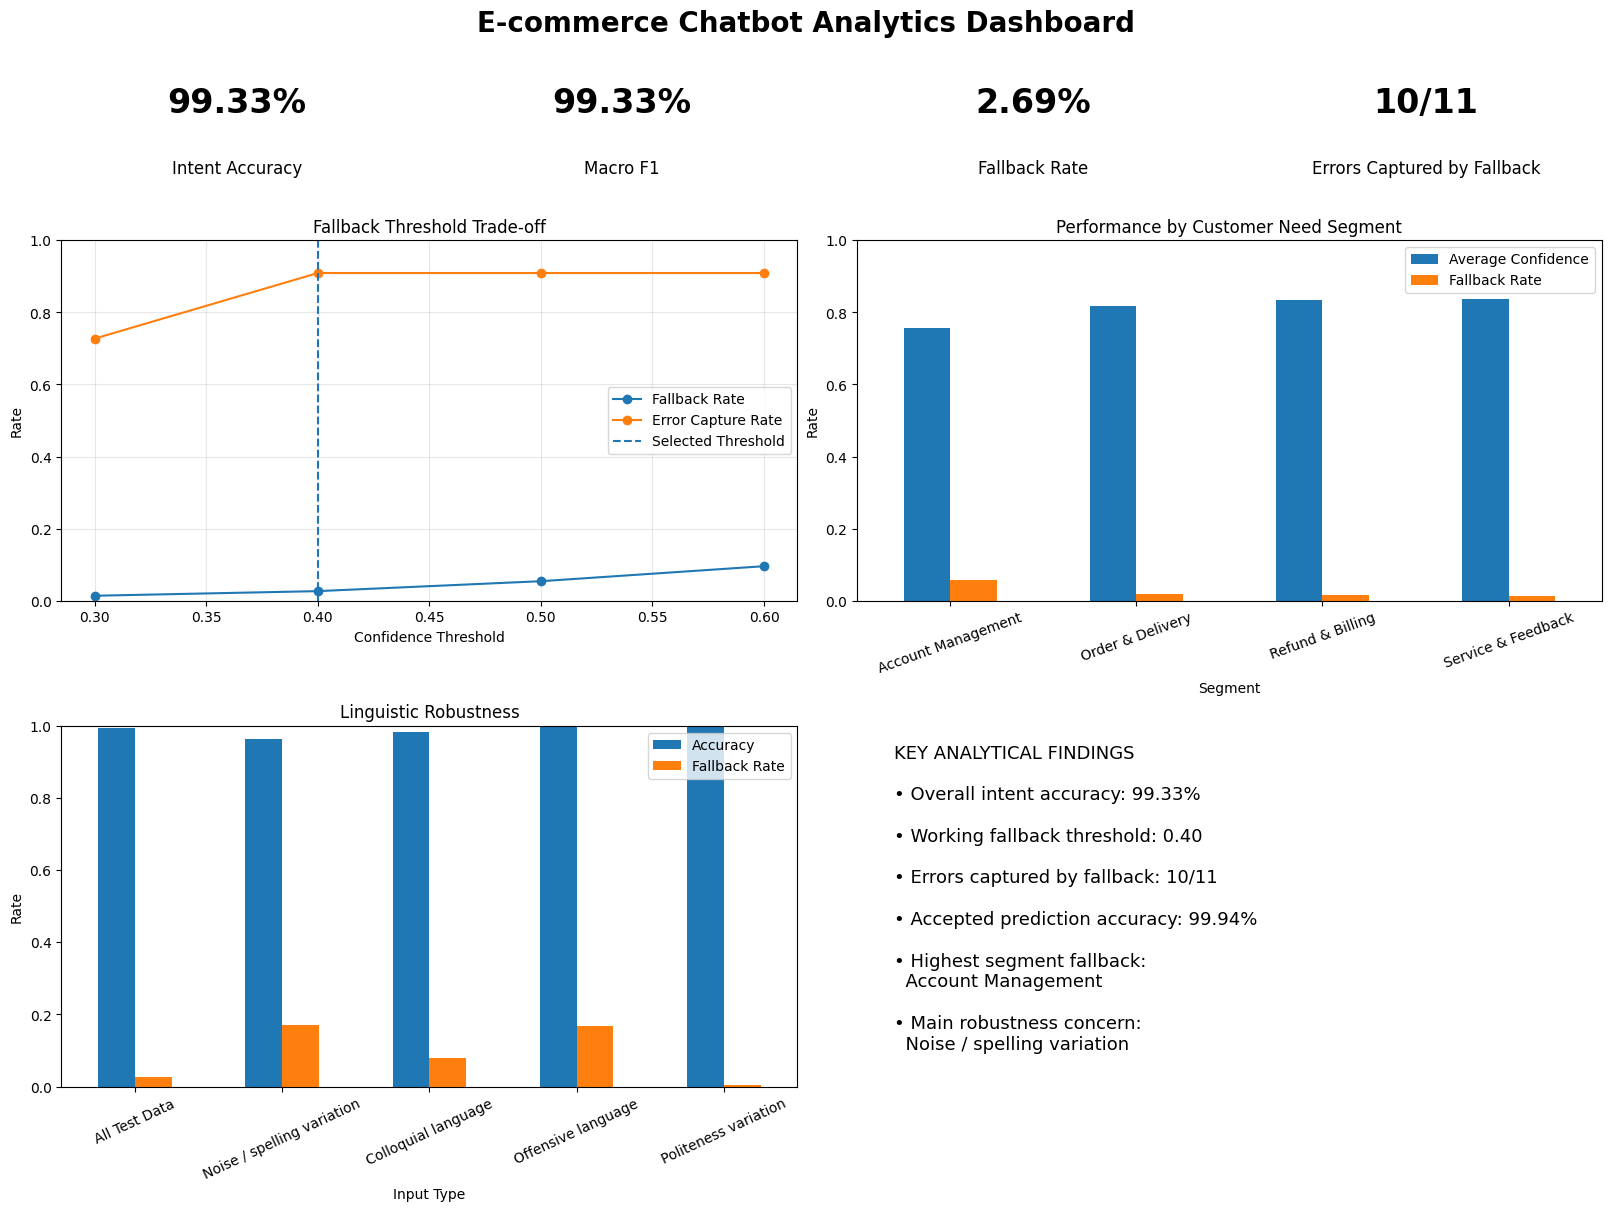

In [50]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fig = plt.figure(
    figsize=(16, 12),
    constrained_layout=True
)

gs = GridSpec(
    3,
    4,
    figure=fig,
    height_ratios=[1, 2.2, 2.2]
)

fig.suptitle(
    "E-commerce Chatbot Analytics Dashboard",
    fontsize=20,
    fontweight="bold"
)


# ------------------------------------------------
# KPI 1
# ------------------------------------------------

ax1 = fig.add_subplot(gs[0, 0])

ax1.text(
    0.5,
    0.65,
    f"{accuracy * 100:.2f}%",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax1.text(
    0.5,
    0.25,
    "Intent Accuracy",
    ha="center",
    va="center",
    fontsize=12
)

ax1.axis("off")


# ------------------------------------------------
# KPI 2
# ------------------------------------------------

ax2 = fig.add_subplot(gs[0, 1])

ax2.text(
    0.5,
    0.65,
    f"{macro_f1 * 100:.2f}%",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax2.text(
    0.5,
    0.25,
    "Macro F1",
    ha="center",
    va="center",
    fontsize=12
)

ax2.axis("off")


# ------------------------------------------------
# KPI 3
# ------------------------------------------------

ax3 = fig.add_subplot(gs[0, 2])

ax3.text(
    0.5,
    0.65,
    f"{fallback_rate * 100:.2f}%",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax3.text(
    0.5,
    0.25,
    "Fallback Rate",
    ha="center",
    va="center",
    fontsize=12
)

ax3.axis("off")


# ------------------------------------------------
# KPI 4
# ------------------------------------------------

ax4 = fig.add_subplot(gs[0, 3])

ax4.text(
    0.5,
    0.65,
    f"{errors_captured}/11",
    ha="center",
    va="center",
    fontsize=24,
    fontweight="bold"
)

ax4.text(
    0.5,
    0.25,
    "Errors Captured by Fallback",
    ha="center",
    va="center",
    fontsize=12
)

ax4.axis("off")


# ------------------------------------------------
# Threshold Analysis
# ------------------------------------------------

ax5 = fig.add_subplot(gs[1, :2])

ax5.plot(
    threshold_results["Threshold"],
    threshold_results["Fallback Rate"],
    marker="o",
    label="Fallback Rate"
)

ax5.plot(
    threshold_results["Threshold"],
    threshold_results["Error Capture Rate"],
    marker="o",
    label="Error Capture Rate"
)

ax5.axvline(
    SELECTED_THRESHOLD,
    linestyle="--",
    label="Selected Threshold"
)

ax5.set_title(
    "Fallback Threshold Trade-off"
)

ax5.set_xlabel(
    "Confidence Threshold"
)

ax5.set_ylabel(
    "Rate"
)

ax5.set_ylim(
    0,
    1
)

ax5.grid(
    alpha=0.3
)

ax5.legend()


# ------------------------------------------------
# Segment Performance
# ------------------------------------------------

ax6 = fig.add_subplot(gs[1, 2:])

segment_dashboard = (
    segment_performance[
        [
            "average_confidence",
            "fallback_rate"
        ]
    ]
)

segment_dashboard.plot(
    kind="bar",
    ax=ax6
)

ax6.set_title(
    "Performance by Customer Need Segment"
)

ax6.set_xlabel(
    "Segment"
)

ax6.set_ylabel(
    "Rate"
)

ax6.set_ylim(
    0,
    1
)

ax6.tick_params(
    axis="x",
    rotation=20
)

ax6.legend(
    [
        "Average Confidence",
        "Fallback Rate"
    ]
)


# ------------------------------------------------
# Linguistic Robustness
# ------------------------------------------------

ax7 = fig.add_subplot(gs[2, :2])

robustness_dashboard = (
    robustness_df
    .set_index("Group")
    [
        [
            "Accuracy",
            "Fallback Rate"
        ]
    ]
)

robustness_dashboard.plot(
    kind="bar",
    ax=ax7
)

ax7.set_title(
    "Linguistic Robustness"
)

ax7.set_xlabel(
    "Input Type"
)

ax7.set_ylabel(
    "Rate"
)

ax7.set_ylim(
    0,
    1
)

ax7.tick_params(
    axis="x",
    rotation=25
)

ax7.legend(
    [
        "Accuracy",
        "Fallback Rate"
    ]
)


# ------------------------------------------------
# Key Findings Panel
# ------------------------------------------------

ax8 = fig.add_subplot(gs[2, 2:])

ax8.axis("off")

key_findings = (
    "KEY ANALYTICAL FINDINGS\n\n"
    "• Overall intent accuracy: "
    f"{accuracy * 100:.2f}%\n\n"

    "• Working fallback threshold: "
    f"{SELECTED_THRESHOLD:.2f}\n\n"

    "• Errors captured by fallback: "
    f"{errors_captured}/11\n\n"

    "• Accepted prediction accuracy: "
    f"{accepted_accuracy * 100:.2f}%\n\n"

    "• Highest segment fallback:\n"
    "  Account Management\n\n"

    "• Main robustness concern:\n"
    "  Noise / spelling variation"
)

ax8.text(
    0.05,
    0.95,
    key_findings,
    va="top",
    fontsize=13
)


# ------------------------------------------------
# SAVE
# ------------------------------------------------

DASHBOARD_PATH = os.path.join(
    FIGURES_DIR,
    "08_chatbot_analytics_dashboard.png"
)

plt.savefig(
    DASHBOARD_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The dashboard shows strong overall intent performance, but also highlights the weaker areas: noisy language, account-management interactions and the trade-off between fallback rate and error capture.

## 10. Summary

- Test accuracy and Macro F1: **99.33%**
- Working fallback threshold: **0.40**
- Errors captured by fallback: **10/11**
- Accepted-prediction accuracy: about **99.94%**
- Main robustness issue: noisy/spelling-variation input
- Highest segment fallback: **Account Management**

The final report will provide the deeper industry interpretation, limitations and optimisation discussion.